In [ ]:
!pip install "datasets<4.0.0" scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd

dataset = load_dataset(
    "bgglue/bgglue",
    "fakenews",
    trust_remote_code=True
)

for split in dataset:
    print(split)
    print(pd.Series(dataset[split]["label"]).value_counts())
    print()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

bgglue.py:   0%|          | 0.00/42.5k [00:00<?, ?B/s]

/root/.cache/huggingface/modules/datasets_modules/datasets/bgglue--bgglue/477308eb155e34576a9e5b68b40ada2186424be7b9c5cd7b20d0d99b6de6bca4/bgglue.py:182: SyntaxWarning: invalid escape sequence '\~'
  Alberto Barr{\'{o}}n{-}Cede{\~{n}}o and
/root/.cache/huggingface/modules/datasets_modules/datasets/bgglue--bgglue/477308eb155e34576a9e5b68b40ada2186424be7b9c5cd7b20d0d99b6de6bca4/bgglue.py:343: SyntaxWarning: invalid escape sequence '\l'
  Marci{\'n}czuk, Micha{\l}  and


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

train
0    1329
1     661
Name: count, dtype: int64

validation
0    144
1     77
Name: count, dtype: int64

test
0    701
Name: count, dtype: int64



In [ ]:
from sklearn.model_selection import train_test_split

full_data = concatenate_datasets([
    dataset["train"],
    dataset["validation"]
])

texts = full_data["content"]
labels = full_data["label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [ ]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

0    1178
1     590
Name: count, dtype: int64
0    295
1    148
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def run_baseline(X_train, X_test, y_train, y_test, title):
    vectorizer = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    print("====", title, "====")
    print("Accuracy :", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall   :", recall_score(y_test, preds))
    print("F1       :", f1_score(y_test, preds))
    print()
    print(classification_report(y_test, preds, target_names=["credible", "fake"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        display_labels=["credible", "fake"]
    )
    plt.title(title)
    plt.show()

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefficients = model.coef_[0]

    top_fake = feature_names[np.argsort(coefficients)[-20:]]
    top_credible = feature_names[np.argsort(coefficients)[:20]]

    return {
        "title": title,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "top_fake": top_fake,
        "top_credible": top_credible,
        "model": model,
        "vectorizer": vectorizer
    }

==== Baseline A: Raw text ====
Accuracy : 0.7065462753950339
Precision: 0.56
Recall   : 0.5675675675675675
F1       : 0.5637583892617449

              precision    recall  f1-score   support

    credible       0.78      0.78      0.78       295
        fake       0.56      0.57      0.56       148

    accuracy                           0.71       443
   macro avg       0.67      0.67      0.67       443
weighted avg       0.71      0.71      0.71       443



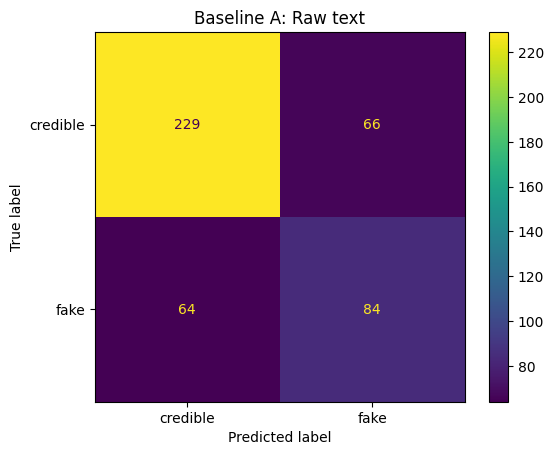

Top fake indicators:
['пак' 'дежурния' 'вашите' 'всяка минута' 'на info' 'за реклама' 'са'
 'варна' 'нешка' 'вече' 'последните новини' 'такива каквито' 'редактор'
 'минута' 'html' 'фокус' 'са от' 'минути' 'petel' 'petel bg']

Top credible indicators:
['източник' '2017' 'коментари' '01' 'bradva' 'петричката' 'bradva bg'
 'видео' 'китай' 'българи' 'ще дойде' 'коментара' 'следете интернет'
 'интернет бъдете' 'интернет' 'дойде' 'февруари 2017' 'ни' 'гости'
 'каза че']


In [ ]:
baseline_raw = run_baseline(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    "Baseline A: Raw text"
)

print("Top fake indicators:")
print(baseline_raw["top_fake"])

print("\nTop credible indicators:")
print(baseline_raw["top_credible"])

In [ ]:
import re

def clean_text(text):
    text = text.lower()

    # remove URLs
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)

    # remove domains
    text = re.sub(r'\b\S+\.(bg|com|net|org|eu|info)\b', ' ', text)

    # remove html-like fragments
    text = re.sub(r'\bhtml\b', ' ', text)
    text = re.sub(r'\bd0\b', ' ', text)

    # remove specific source names that appeared as leakage
    leakage_terms = [
        "petel", "bradva", "skafeto", "fakti", "pik", "blitz"
    ]

    for term in leakage_terms:
        text = re.sub(rf'\b{term}\b', ' ', text)

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
X_train_clean = [clean_text(x) for x in X_train_raw]
X_test_clean = [clean_text(x) for x in X_test_raw]

==== Baseline B: Cleaned text ====
Accuracy : 0.7042889390519187
Precision: 0.5578231292517006
Recall   : 0.5540540540540541
F1       : 0.5559322033898305

              precision    recall  f1-score   support

    credible       0.78      0.78      0.78       295
        fake       0.56      0.55      0.56       148

    accuracy                           0.70       443
   macro avg       0.67      0.67      0.67       443
weighted avg       0.70      0.70      0.70       443



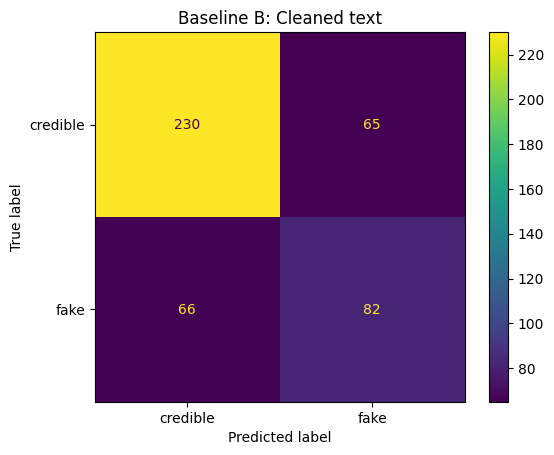

Top fake indicators:
['варна изпращайте' 'българия варна' 'следете всяка' 'реклама бъдете'
 'на дежурния' 'вашите снимки' 'часа денонощието' 'изпращайте вашите'
 'дежурния' 'вашите' 'всяка минута' 'за реклама' 'варна'
 'последните новини' 'фокус' 'такива каквито' 'редактор' 'минута' 'са от'
 'минути']

Top credible indicators:
['източник' '2017' 'коментари' '01' 'следете интернет' 'интернет бъдете'
 'интернет' 'петричката' 'видео' 'коментара' 'българи' 'китай' 'ще дойде'
 'дойде' 'гости' 'ни' 'февруари 2017' 'каза че' 'comments' 'времена']


In [ ]:
baseline_clean = run_baseline(
    X_train_clean,
    X_test_clean,
    y_train,
    y_test,
    "Baseline B: Cleaned text"
)

print("Top fake indicators:")
print(baseline_clean["top_fake"])

print("\nTop credible indicators:")
print(baseline_clean["top_credible"])

In [ ]:
results = pd.DataFrame([
    {
        "model": baseline_raw["title"],
        "accuracy": baseline_raw["accuracy"],
        "precision": baseline_raw["precision"],
        "recall": baseline_raw["recall"],
        "f1": baseline_raw["f1"]
    },
    {
        "model": baseline_clean["title"],
        "accuracy": baseline_clean["accuracy"],
        "precision": baseline_clean["precision"],
        "recall": baseline_clean["recall"],
        "f1": baseline_clean["f1"]
    }
])

results

,model,accuracy,precision,recall,f1
0,Baseline A: Raw text,0.706546,0.560000,0.567568,0.563758
1,Baseline B: Cleaned text,0.704289,0.557823,0.554054,0.555932
